In [24]:
# https://pypi.org/project/rasterfairy-py3/#description
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterfairy
from collections import defaultdict
from matplotlib.cm import get_cmap
np.float = float

In [25]:
# Load the JSON data
with open(r"visualisation/video_tsne_enriched_data_viz_without_base64.json", "r") as f:
    data = json.load(f)

len(data)

1472

In [26]:
tsne_result = np.array([item["reduced_embedding"] for item in data])
clusters = [item["cluster"] for item in data]

unique_clusters = sorted(set(clusters))
cluster_to_id = {cluster: idx for idx, cluster in enumerate(unique_clusters)}
cluster_ids = np.array([cluster_to_id[c] for c in clusters])

cmap = get_cmap("tab20")  # Up to 20 distinct colors
colors = [cmap(i % 20) for i in cluster_ids]

/tmp/ipykernel_100996/3844498911.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")  # Up to 20 distinct colors


In [27]:
# RasterFairy grid transformation
transformed, grid_assignments = rasterfairy.transformPointCloud2D(tsne_result)

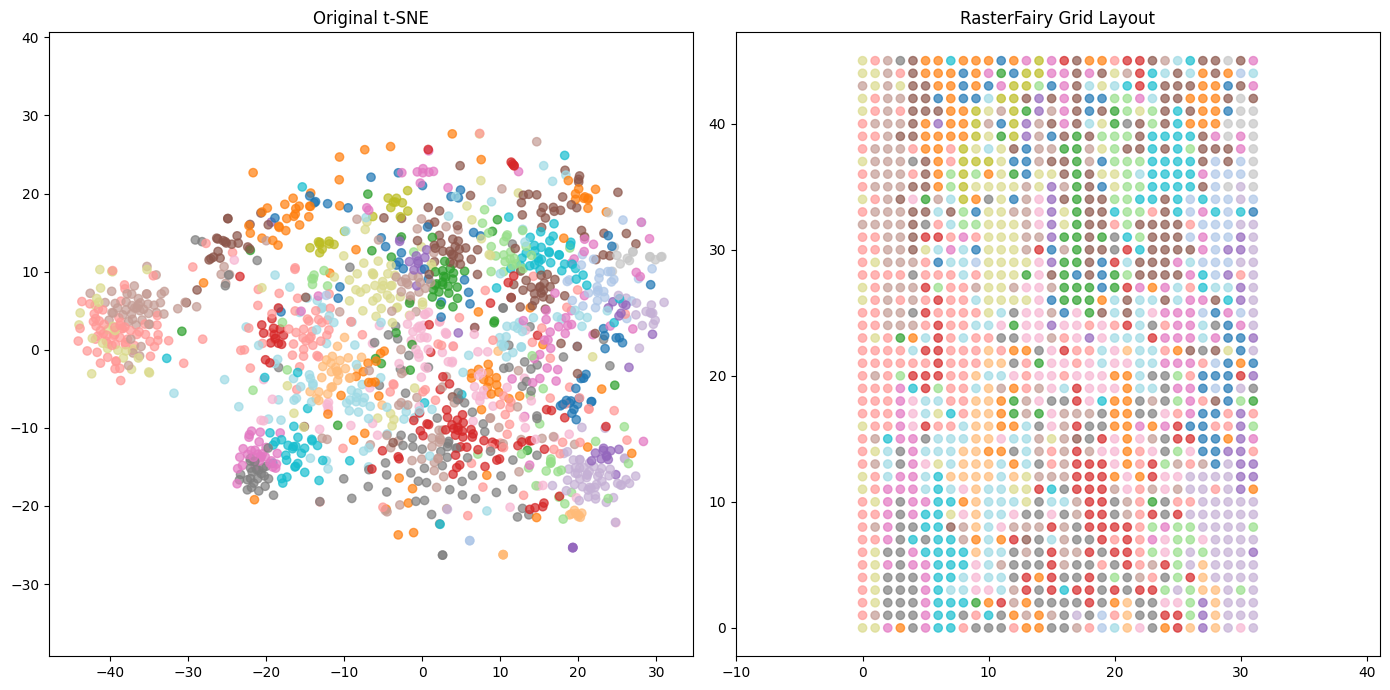

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Original t-SNE
axes[0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=colors, alpha=0.7)
axes[0].set_title('Original t-SNE')
axes[0].axis('equal')

# RasterFairy-aligned grid
axes[1].scatter(transformed[:, 0], transformed[:, 1], c=colors, alpha=0.7)
axes[1].set_title('RasterFairy Grid Layout')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [29]:
x_min, x_max = np.min(transformed[:, 0]), np.max(transformed[:, 0])
y_min, y_max = np.min(transformed[:, 1]), np.max(transformed[:, 1])

print(f"X range: {x_min} to {x_max}")
print(f"Y range: {y_min} to {y_max}")

X range: 0.0 to 31.0
Y range: 0.0 to 45.0


In [30]:
transformed

array([[29., 35.],
       [ 1., 34.],
       [ 0., 28.],
       ...,
       [31., 17.],
       [14., 34.],
       [ 6., 38.]])

In [31]:
for idx, item in enumerate(data):
    item["rasterfairy_coordinates"] = transformed[idx].tolist()

In [32]:
with open(r"visualisation/video_tsne_enriched_data_viz_without_base64.json", "w") as f:
    json.dump(data, f, indent=2)

In [33]:
print(json.dumps(data[0], indent=4))

{
    "payload": {
        "video_id": "DI3VngZvkSu",
        "video_path": "/home/aatman/Aatman/Tattle/tattle-research/brainrot/main_analysis_2/visualisation/video_reels/DI3VngZvkSu.mp4",
        "thumbnail_path": "thumbnails/DI3VngZvkSu.jpg",
        "id": "DI3VngZvkSu",
        "day": 4,
        "zero_shot_prediction": "screen capture",
        "cluster": "22"
    },
    "reduced_embedding": [
        24.375722885131836,
        10.035624504089355
    ],
    "reduced_embedding_normalized": [
        0.9117235842666586,
        0.672933235498815
    ],
    "cluster": "22",
    "rasterfairy_coordinates": [
        29.0,
        35.0
    ]
}
